In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Load the dataset
df = pd.read_csv('ai_job_trends_dataset.csv')

# 2. Standardize Column Names (Best Practice)
# This replaces spaces with underscores and makes everything lowercase
# so you don't have to type df['Median Salary (USD)'] every time.
df.columns = df.columns.str.lower().str.replace(' ', '_').str.replace('(', '').str.replace(')', '').str.replace('%', 'pct')
df.columns = df.columns.str.lower().str.replace(' ', '_').str.replace('\(', '', regex=True).str.replace('\)', '', regex=True).str.replace('%', 'pct')
# 3. Feature Engineering (Helpful for your Analysis)
# Your proposal mentions workforce planning based on 2024 vs 2030 openings.
# Let's create a column that shows the percentage growth (or decline) in jobs.
df['job_growth_pct'] = ((df['projected_openings_2030'] - df['job_openings_2024']) / df['job_openings_2024']) * 100

# 4. Categorical Encoding (Required for Machine Learning)
# Machine learning models (like clustering/regression) require numbers, not text.

# A. Ordinal Encoding (For categories that have a natural order/ranking)
# Education level has a clear order:
education_mapping = {
    'High School': 1,
    'Associate Degree': 2,
    'Bachelor’s Degree': 3,
    'Master’s Degree': 4,
    'Ph.D.': 5
}
df['required_education_encoded'] = df['required_education'].map(education_mapping)

# AI Impact Level has a clear order:
impact_mapping = {
    'Low': 1,
    'Moderate': 2,
    'High': 3
}
df['ai_impact_level_encoded'] = df['ai_impact_level'].map(impact_mapping)

# B. One-Hot Encoding (For categories without a ranking)
# Industry and Location don't have a numerical rank, so we create binary columns.
df = pd.get_dummies(df, columns=['industry', 'location'], drop_first=True)

# 5. Review the final preprocessed dataframe
print("Data preprocessing complete!")
print("New shape of dataset:", df.shape)
print(df.head())

# 6. Save the cleaned and processed data to a new file
# df.to_csv('cleaned_ai_job_trends.csv', index=False)

Data preprocessing complete!
New shape of dataset: (30000, 28)
               job_title  job_status ai_impact_level  median_salary_usd  \
0     Investment analyst  Increasing        Moderate           42109.76   
1  Journalist, newspaper  Increasing        Moderate          132298.57   
2      Financial planner  Increasing             Low          143279.19   
3        Legal secretary  Increasing            High           97576.13   
4  Aeronautical engineer  Increasing             Low           60956.63   

  required_education  experience_required_years  job_openings_2024  \
0    Master’s Degree                          5               1515   
1    Master’s Degree                         15               1243   
2  Bachelor’s Degree                          4               3338   
3   Associate Degree                         15               7173   
4    Master’s Degree                         13               5944   

   projected_openings_2030  remote_work_ratio_pct  automation_ris

<>:13: SyntaxWarning: invalid escape sequence '\('
<>:13: SyntaxWarning: invalid escape sequence '\)'
<>:13: SyntaxWarning: invalid escape sequence '\('
<>:13: SyntaxWarning: invalid escape sequence '\)'
/tmp/ipykernel_5851/1592393766.py:13: SyntaxWarning: invalid escape sequence '\('
  df.columns = df.columns.str.lower().str.replace(' ', '_').str.replace('\(', '', regex=True).str.replace('\)', '', regex=True).str.replace('%', 'pct')
/tmp/ipykernel_5851/1592393766.py:13: SyntaxWarning: invalid escape sequence '\)'
  df.columns = df.columns.str.lower().str.replace(' ', '_').str.replace('\(', '', regex=True).str.replace('\)', '', regex=True).str.replace('%', 'pct')


In [8]:
sns.set_theme(style="whitegrid")

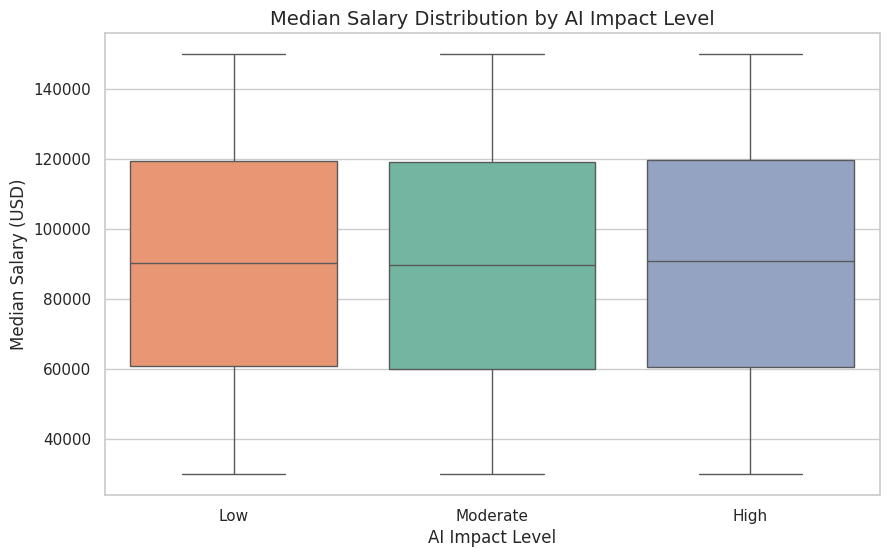

In [9]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='ai_impact_level', y='median_salary_usd', order=['Low', 'Moderate', 'High'], palette="Set2", hue='ai_impact_level', legend=False)
plt.title('Median Salary Distribution by AI Impact Level', fontsize=14)
plt.xlabel('AI Impact Level')
plt.ylabel('Median Salary (USD)')
plt.savefig('salary_by_ai_impact.png', bbox_inches='tight')
plt.show()

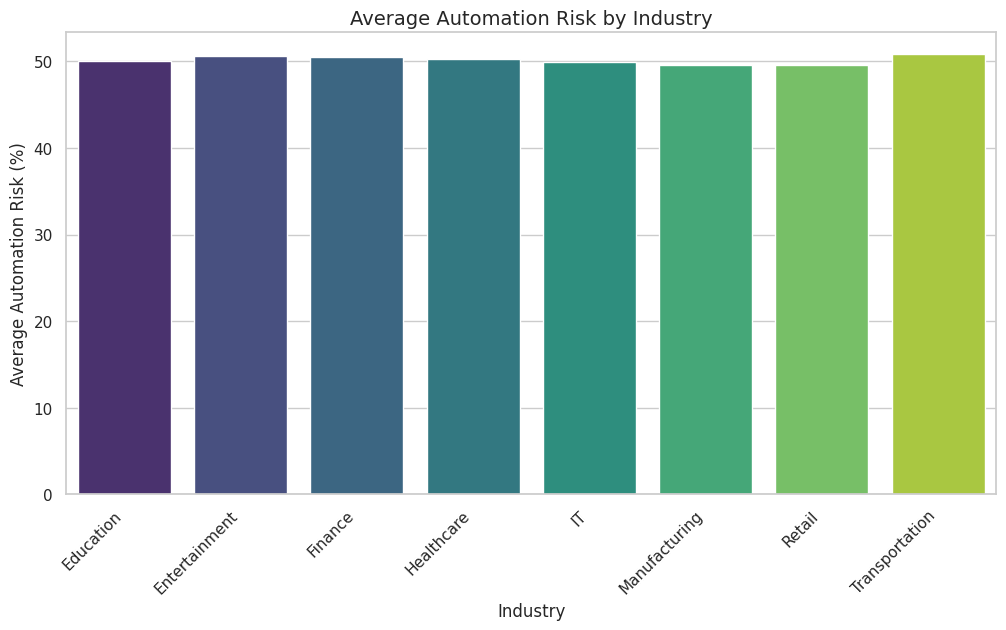

In [27]:
# Calculate average automation risk by industry
risk_by_industry = df_dash.groupby('industry')['automation_risk_pct'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=risk_by_industry, x='industry', y='automation_risk_pct', palette="viridis", hue='industry', legend=False)
plt.title('Average Automation Risk by Industry', fontsize=14)
plt.xlabel('Industry')
plt.ylabel('Average Automation Risk (%)')
plt.xticks(rotation=45, ha='right')
plt.savefig('automation_risk_by_industry.png', bbox_inches='tight')
plt.show()

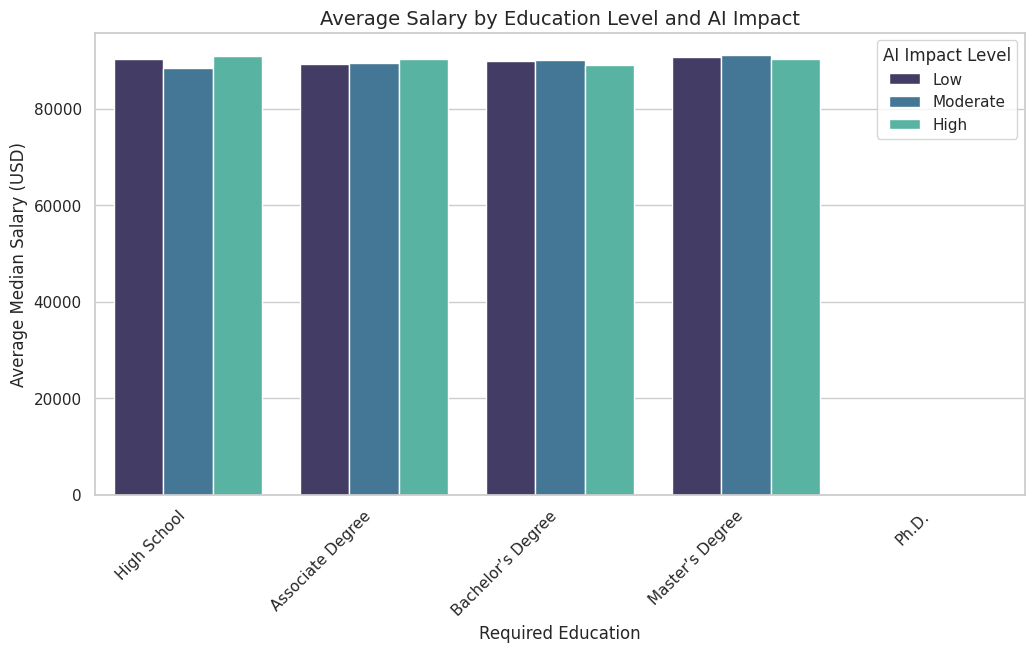

In [12]:
plt.figure(figsize=(12, 6))
edu_order = ['High School', 'Associate Degree', 'Bachelor’s Degree', 'Master’s Degree', 'Ph.D.']
sns.barplot(data=df, x='required_education', y='median_salary_usd', hue='ai_impact_level',
            order=edu_order, hue_order=['Low', 'Moderate', 'High'], palette="mako", errorbar=None)
plt.title('Average Salary by Education Level and AI Impact', fontsize=14)
plt.xlabel('Required Education')
plt.ylabel('Average Median Salary (USD)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='AI Impact Level')
plt.savefig('education_vs_salary.png', bbox_inches='tight')
plt.show()

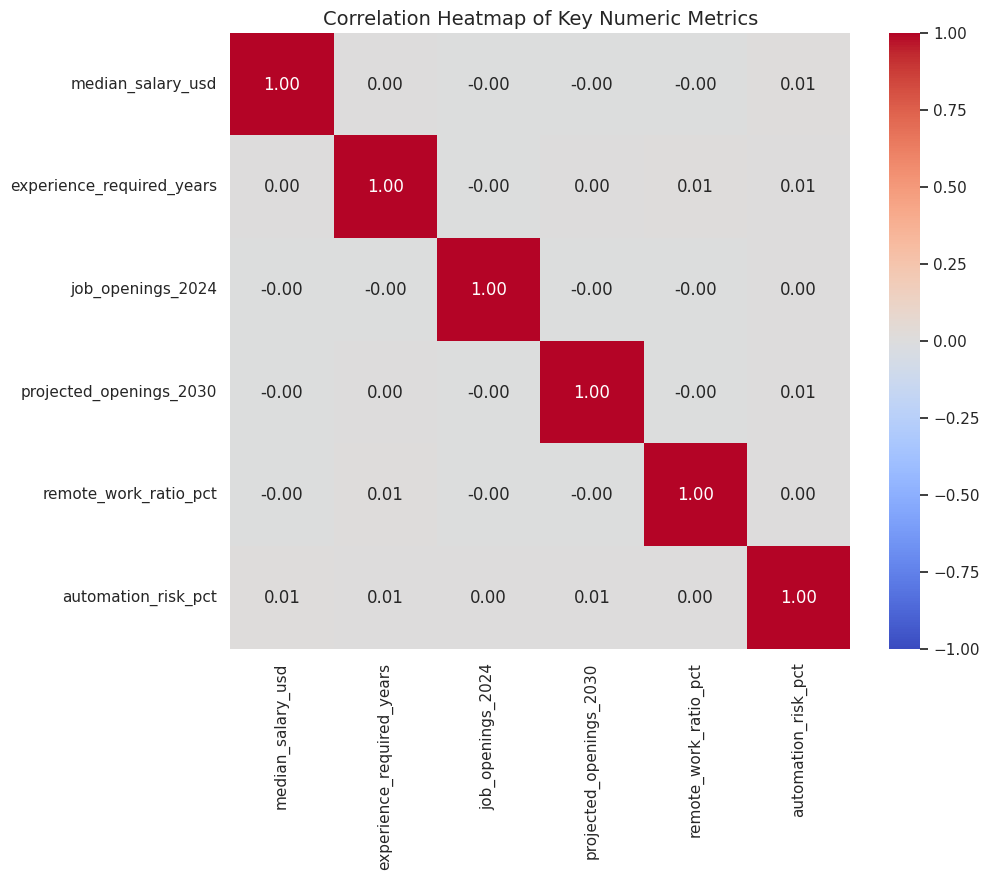

In [13]:
plt.figure(figsize=(10, 8))
corr_cols = ['median_salary_usd', 'experience_required_years', 'job_openings_2024',
             'projected_openings_2030', 'remote_work_ratio_pct', 'automation_risk_pct']
corr_matrix = df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Key Numeric Metrics', fontsize=14)
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

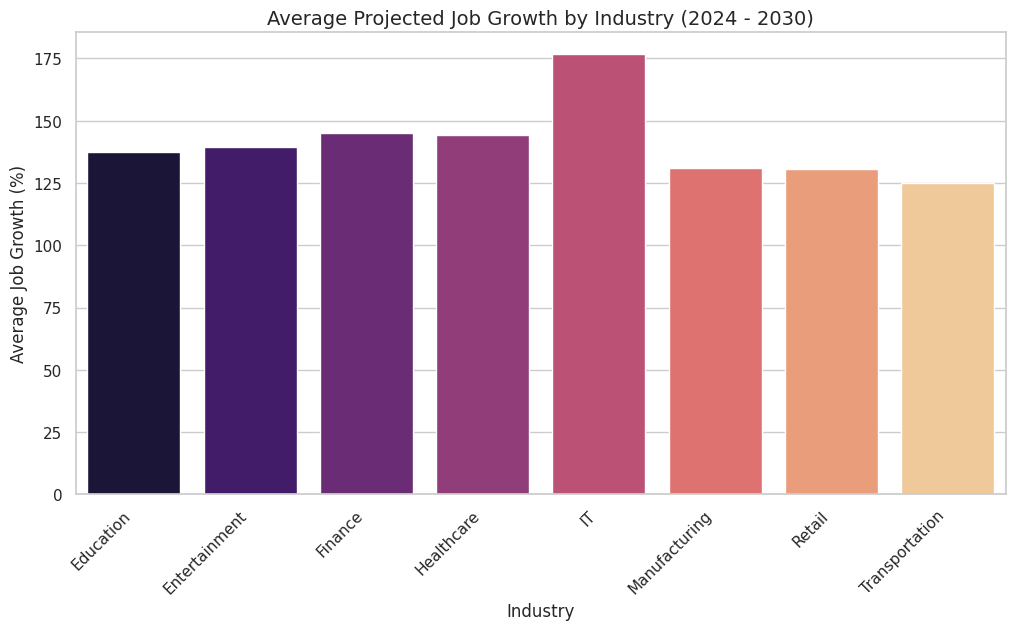

In [31]:
df_dash['job_growth_pct'] = ((df_dash['projected_openings_2030'] - df_dash['job_openings_2024']) / df_dash['job_openings_2024']) * 100
growth_by_industry = df_dash.groupby('industry')['job_growth_pct'].mean().reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(data=growth_by_industry, x='industry', y='job_growth_pct', palette="magma", hue='industry', legend=False)
plt.title('Average Projected Job Growth by Industry (2024 - 2030)', fontsize=14)
plt.xlabel('Industry')
plt.ylabel('Average Job Growth (%)')
plt.xticks(rotation=45, ha='right')
plt.savefig('job_growth_by_industry.png', bbox_inches='tight')
plt.show()

In [15]:
print("EDA visualisations generated successfully!")

EDA visualisations generated successfully!


In [16]:
print("\n--- Average Salary by AI Impact ---")
print(df.groupby('ai_impact_level')['median_salary_usd'].mean())


--- Average Salary by AI Impact ---
ai_impact_level
High        90354.781024
Low         90265.040301
Moderate    89742.226538
Name: median_salary_usd, dtype: float64


In [32]:
print("\n--- Average Automation Risk by Industry ---")
print(risk_by_industry.set_index('industry').sort_values(by='automation_risk_pct', ascending=False))


--- Average Automation Risk by Industry ---
                automation_risk_pct
industry                           
Transportation            50.790645
Entertainment             50.587905
Finance                   50.506203
Healthcare                50.267560
Education                 50.013546
IT                        49.876338
Retail                    49.608512
Manufacturing             49.586010


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import r2_score, accuracy_score

print("\nStarting Machine Learning Pipeline...")


Starting Machine Learning Pipeline...


In [19]:
df_ml = pd.get_dummies(df, columns=['job_status', 'required_education', 'ai_impact_level'], drop_first=True)

# Machine learning models can't handle missing/infinite values well.
df_ml.replace([np.inf, -np.inf], np.nan, inplace=True)
df_ml.dropna(inplace=True)

In [20]:
print("\n--- 1. Regression Analysis ---")
# We will try to predict Salary based on all other numerical metrics
X_reg = df_ml.drop(['median_salary_usd', 'job_title'], axis=1)
y_reg = df_ml['median_salary_usd']


--- 1. Regression Analysis ---


In [21]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

reg_model = LinearRegression()
reg_model.fit(X_train_reg, y_train_reg)
y_pred_reg = reg_model.predict(X_test_reg)

r2 = r2_score(y_test_reg, y_pred_reg)
print(f"R-squared for Salary Prediction: {r2:.4f}")

R-squared for Salary Prediction: -0.0029



--- 2. Decision Tree Classification ---
Decision Tree Accuracy: 0.3213


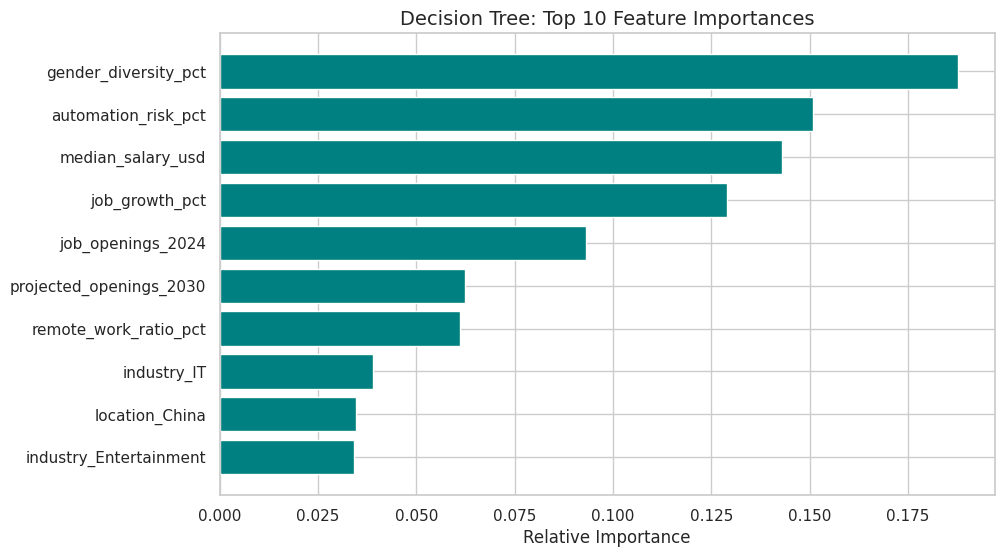

In [22]:
print("\n--- 2. Decision Tree Classification ---")
# We will predict the 'AI Impact Level' based on the job's features
X_dt = df_ml.drop([col for col in df_ml.columns if 'ai_impact' in col] + ['job_title'], axis=1)

# Grab the encoded impact level from the original dataframe
# (make sure we drop identical NaNs so the lengths match)
df_clean = df.replace([np.inf, -np.inf], np.nan).dropna()
y_dt = df_clean['ai_impact_level_encoded']

X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(X_dt, y_dt, test_size=0.2, random_state=42)

# Train the Decision Tree
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train_dt, y_train_dt)
y_pred_dt = dt_model.predict(X_test_dt)

acc = accuracy_score(y_test_dt, y_pred_dt)
print(f"Decision Tree Accuracy: {acc:.4f}")

# Plot: Top 10 Feature Importances for the Decision Tree
features = X_dt.columns
importances = dt_model.feature_importances_
indices = np.argsort(importances)[-10:] # Get top 10

plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importances[indices], color='teal', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.title('Decision Tree: Top 10 Feature Importances', fontsize=14)
plt.xlabel('Relative Importance')
plt.savefig('dt_feature_importance.png', bbox_inches='tight')
plt.show()


--- 3. K-Means Clustering ---


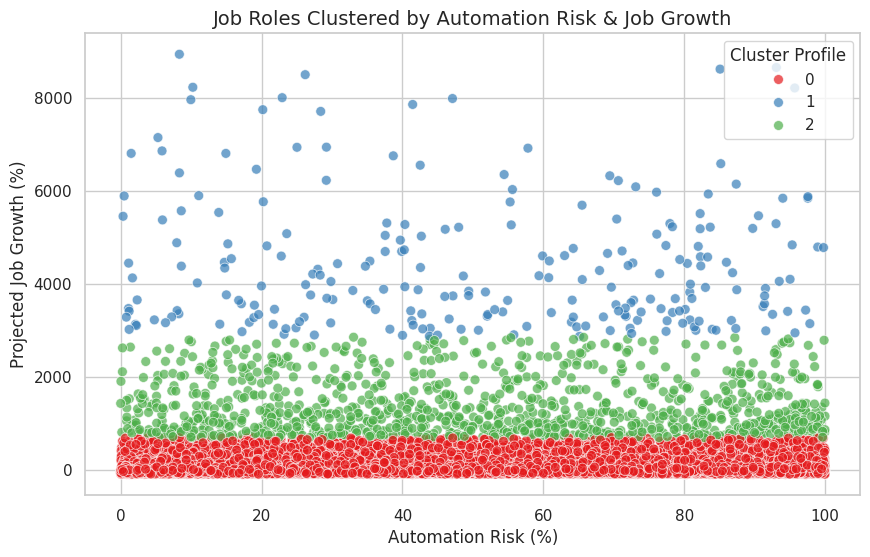

In [23]:
print("\n--- 3. K-Means Clustering ---")
# We cluster jobs based on their Automation Risk and projected Job Growth
cluster_data = df_clean[['automation_risk_pct', 'job_growth_pct']]

# We ask the algorithm to find 3 distinct clusters (e.g., High, Med, Low risk profiles)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clean['cluster'] = kmeans.fit_predict(cluster_data)

# Plot the clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='automation_risk_pct', y='job_growth_pct', hue='cluster', palette='Set1', s=50, alpha=0.7)
plt.title('Job Roles Clustered by Automation Risk & Job Growth', fontsize=14)
plt.xlabel('Automation Risk (%)')
plt.ylabel('Projected Job Growth (%)')
plt.legend(title='Cluster Profile')
plt.savefig('kmeans_clusters.png', bbox_inches='tight')
plt.show()

In [24]:
# Save the final dataset with the ML clusters to a CSV file
df_clean.to_csv('final_dashboard_data.csv', index=False)
print("Data saved for Power BI!")

Data saved for Power BI!


In [25]:
import pandas as pd
from sklearn.cluster import KMeans

print("Generating clean Power BI dataset...")

# 1. Load the original fresh data
df_dash = pd.read_csv('ai_job_trends_dataset.csv')

# 2. Clean column names
df_dash.columns = df_dash.columns.str.lower().str.replace(' ', '_').str.replace('\(', '', regex=True).str.replace('\)', '', regex=True).str.replace('%', 'pct')

# 3. Recreate the Job Growth metric
df_dash['job_growth_pct'] = ((df_dash['projected_openings_2030'] - df_dash['job_openings_2024']) / df_dash['job_openings_2024']) * 100

# 4. Recreate the 3 Clusters
# Fill any infinity/NaN values with 0 just to be safe
cluster_data = df_dash[['automation_risk_pct', 'job_growth_pct']].replace([float('inf'), -float('inf')], 0).fillna(0)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_dash['cluster'] = kmeans.fit_predict(cluster_data)

# 5. Export this clean, non-dummified data!
df_dash.to_csv('powerbi_dashboard_data.csv', index=False)
print("Success! File saved as: powerbi_dashboard_data.csv")

<>:10: SyntaxWarning: invalid escape sequence '\('
<>:10: SyntaxWarning: invalid escape sequence '\)'
<>:10: SyntaxWarning: invalid escape sequence '\('
<>:10: SyntaxWarning: invalid escape sequence '\)'
/tmp/ipykernel_5851/3490510831.py:10: SyntaxWarning: invalid escape sequence '\('
  df_dash.columns = df_dash.columns.str.lower().str.replace(' ', '_').str.replace('\(', '', regex=True).str.replace('\)', '', regex=True).str.replace('%', 'pct')
/tmp/ipykernel_5851/3490510831.py:10: SyntaxWarning: invalid escape sequence '\)'
  df_dash.columns = df_dash.columns.str.lower().str.replace(' ', '_').str.replace('\(', '', regex=True).str.replace('\)', '', regex=True).str.replace('%', 'pct')


Generating clean Power BI dataset...
Success! File saved as: powerbi_dashboard_data.csv
